# Best Hiring Season Analysis, US Machine Learning Jobs

Exploring 997 US-based ML job postings from Kaggle. See the README for
full project background and findings. This notebook covers the step by
step cleaning and analysis process.

## Step 1: Load the data and take a first look

In [22]:
import pandas as pd

df = pd.read_csv("1000_ml_jobs_us.csv")

print(df.shape)
print(df.columns.tolist())

(997, 10)
['Unnamed: 0', 'job_posted_date', 'company_address_locality', 'company_address_region', 'company_name', 'company_website', 'company_description', 'job_description_text', 'seniority_level', 'job_title']


In [23]:
df.head(5)

,Unnamed: 0,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title
0,0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...
1,1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer
2,2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer
3,3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training"
4,4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer


## Step 2: Convert dates and check data coverage

The `job_posted_date` column loads as plain text by default, so we convert
it to a proper datetime type, then extract year and month to check how
evenly the data is spread across time.

In [24]:
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

print(df["job_posted_date"].dtype)
print(df["job_posted_date"].min(), df["job_posted_date"].max())

datetime64[us]
2022-12-20 00:00:00 2025-04-09 00:00:00


In [25]:
df["year"] = df["job_posted_date"].dt.year
df["month"] = df["job_posted_date"].dt.month

print(df["year"].value_counts().sort_index())

year
2022      1
2023      2
2024     74
2025    920
Name: count, dtype: int64


In [26]:
print(df["month"].value_counts().sort_index())
print(df[df["year"] == 2025]["month"].value_counts().sort_index())

month
1      28
2      34
3     426
4     433
5       1
6       7
7       3
8       6
9       4
10      8
11     15
12     32
Name: count, dtype: int64
month
1     28
2     34
3    425
4    433
Name: count, dtype: int64


## Step 3: Clean and standardize location data

The `company_address_region` column contains inconsistent formatting
(e.g. "CA" vs "California" vs "CALIFORNIA") and includes non-US locations
(UK, India, Canada, etc.). This section standardizes formatting first,
then filters the dataset down to recognized US states only.

In [27]:
print(df["company_address_region"].unique())

<StringArray>
[             'Indiana',           'California',                   'CA',
        'Massachusetts',                   'IL',          'Maharashtra',
       'United Kingdom',                   'MD',                    nan,
             'New York',                  'NSW',                   'TX',
                   'NY',                   'DC',                   'FL',
             'Arkansas',             'Delaware',                   'GA',
                   'ON',                   'NJ',                   'WA',
                   'NC',            'Karnataka',              'Ontario',
              'Florida',            'Guangdong',           'Washington',
                   '北京',           'CALIFORNIA',                   'MA',
              'England',                   'CO',                   'PA',
              'Bavaria',            'Minnesota',              'Georgia',
               'Nevada',             'Illinois',                   'AR',
              'Alabama',             

In [28]:
df["region_clean"] = df["company_address_region"].str.strip().str.upper()

print(df["region_clean"].unique())

<StringArray>
[             'INDIANA',           'CALIFORNIA',                   'CA',
        'MASSACHUSETTS',                   'IL',          'MAHARASHTRA',
       'UNITED KINGDOM',                   'MD',                    nan,
             'NEW YORK',                  'NSW',                   'TX',
                   'NY',                   'DC',                   'FL',
             'ARKANSAS',             'DELAWARE',                   'GA',
                   'ON',                   'NJ',                   'WA',
                   'NC',            'KARNATAKA',              'ONTARIO',
              'FLORIDA',            'GUANGDONG',           'WASHINGTON',
                   '北京',                   'MA',              'ENGLAND',
                   'CO',                   'PA',              'BAVARIA',
            'MINNESOTA',              'GEORGIA',               'NEVADA',
             'ILLINOIS',                   'AR',              'ALABAMA',
              'ARIZONA', 'DISTRICT OF

### Mapping abbreviations to full state names, and filtering to US-only rows

A manually built dictionary maps two-letter abbreviations to full state
names, so entries like "CA" and "California" are treated as identical.
Rows that don't match any recognized US state (non-US countries, or
invalid values like stray zip codes) are excluded, with one exception:
a known zip code (94086, Sunnyvale) was manually corrected to California
rather than dropped, since it was a clearly identifiable, recoverable value.

In [29]:
zip_fixes = {
    "94086": "CALIFORNIA"
}

df["region_clean"] = df["region_clean"].replace(zip_fixes)

In [30]:
us_states = {
    "AL": "ALABAMA", "AK": "ALASKA", "AZ": "ARIZONA", "AR": "ARKANSAS",
    "CA": "CALIFORNIA", "CO": "COLORADO", "CT": "CONNECTICUT", "DE": "DELAWARE",
    "FL": "FLORIDA", "GA": "GEORGIA", "HI": "HAWAII", "ID": "IDAHO",
    "IL": "ILLINOIS", "IN": "INDIANA", "IA": "IOWA", "KS": "KANSAS",
    "KY": "KENTUCKY", "LA": "LOUISIANA", "ME": "MAINE", "MD": "MARYLAND",
    "MA": "MASSACHUSETTS", "MI": "MICHIGAN", "MN": "MINNESOTA", "MS": "MISSISSIPPI",
    "MO": "MISSOURI", "MT": "MONTANA", "NE": "NEBRASKA", "NV": "NEVADA",
    "NH": "NEW HAMPSHIRE", "NJ": "NEW JERSEY", "NM": "NEW MEXICO", "NY": "NEW YORK",
    "NC": "NORTH CAROLINA", "ND": "NORTH DAKOTA", "OH": "OHIO", "OK": "OKLAHOMA",
    "OR": "OREGON", "PA": "PENNSYLVANIA", "RI": "RHODE ISLAND", "SC": "SOUTH CAROLINA",
    "SD": "SOUTH DAKOTA", "TN": "TENNESSEE", "TX": "TEXAS", "UT": "UTAH",
    "VT": "VERMONT", "VA": "VIRGINIA", "WA": "WASHINGTON", "WV": "WEST VIRGINIA",
    "WI": "WISCONSIN", "WY": "WYOMING", "DC": "DISTRICT OF COLUMBIA"
}

valid_regions = set(us_states.keys()) | set(us_states.values())

df["region_std"] = df["region_clean"].replace(us_states)

is_valid_us = df["region_std"].isin(valid_regions)
print(df.loc[~is_valid_us, "region_clean"].value_counts())

region_clean
ENGLAND           14
LONDON            10
MAHARASHTRA        4
ONTARIO            4
BAVARIA            4
CHINA              4
UNITED KINGDOM     3
GUANGDONG          3
.                  3
MH                 3
NSW                2
ON                 1
KARNATAKA          1
北京                 1
GYEONGGI-DO        1
ESSEX              1
ÎLE-DE-FRANCE      1
CHILE              1
GREATER LONDON     1
COUNTY DUBLIN      1
TOKYO              1
BC                 1
Name: count, dtype: int64


In [31]:
df_us = df[is_valid_us].copy()

print(df.shape)
print(df_us.shape)

(997, 14)
(819, 14)


## Step 4: Geographic concentration of ML job postings

California dominates the dataset overwhelmingly, and within California,
postings cluster heavily around the San Francisco Bay Area specifically
(San Francisco, Menlo Park, San Jose, Mountain View, and Los Gatos all
appear in the top 10 cities).

In [32]:
import matplotlib.pyplot as plt

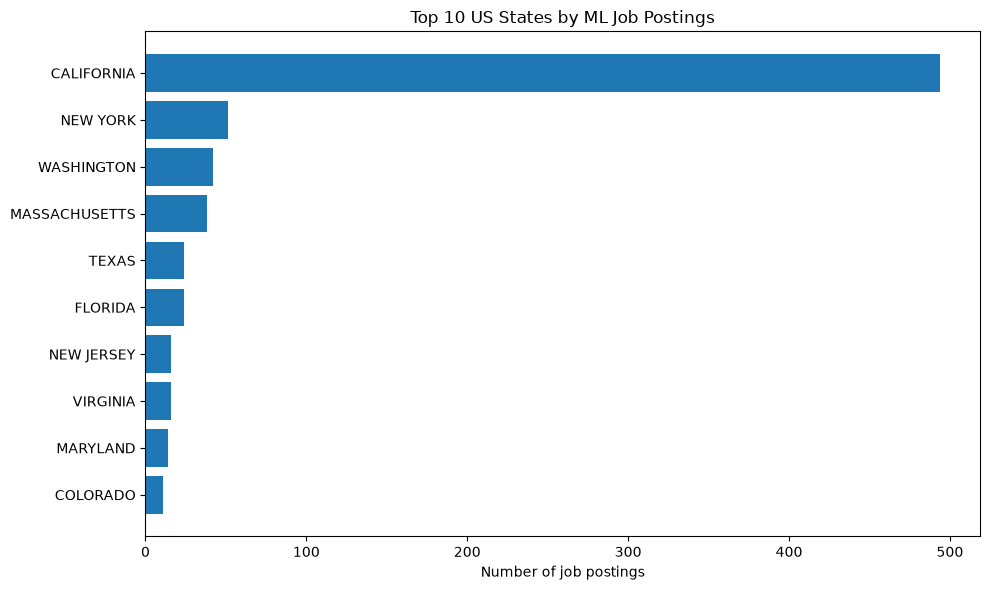

In [33]:
top_states = df_us["region_std"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_states.index[::-1], top_states.values[::-1])
plt.xlabel("Number of job postings")
plt.title("Top 10 US States by ML Job Postings")
plt.tight_layout()
plt.show()

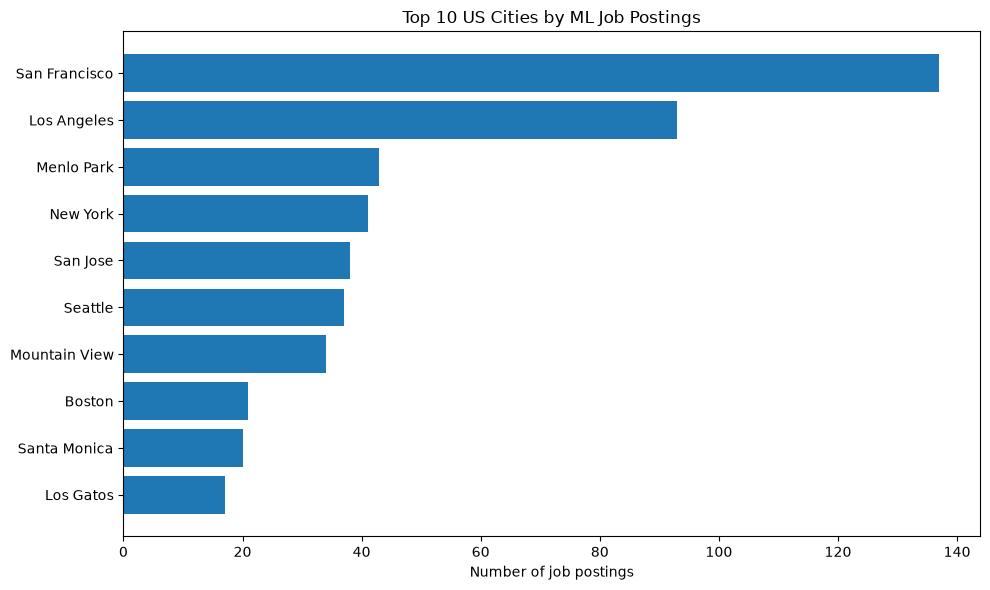

In [34]:
top_cities = df_us["company_address_locality"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cities.index[::-1], top_cities.values[::-1])
plt.xlabel("Number of job postings")
plt.title("Top 10 US Cities by ML Job Postings")
plt.tight_layout()
plt.show()

## Step 5: Day-of-week posting patterns

Since the monthly "season" signal is compromised by the scraping bias noted
above, day-of-week is a more reliable timing angle within the March-April
window this dataset actually covers well. Wednesday shows a notable spike
in postings, worth further investigation into whether this reflects real
hiring behavior or scraping timing, it cannot be confirmed with certainty
from this data alone.

In [36]:
df_us["day_of_week"] = df_us["job_posted_date"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df_us["day_of_week"].value_counts().reindex(day_order)

print(day_counts)

day_of_week
Monday       107
Tuesday      139
Wednesday    222
Thursday     116
Friday       124
Saturday      60
Sunday        51
Name: count, dtype: int64


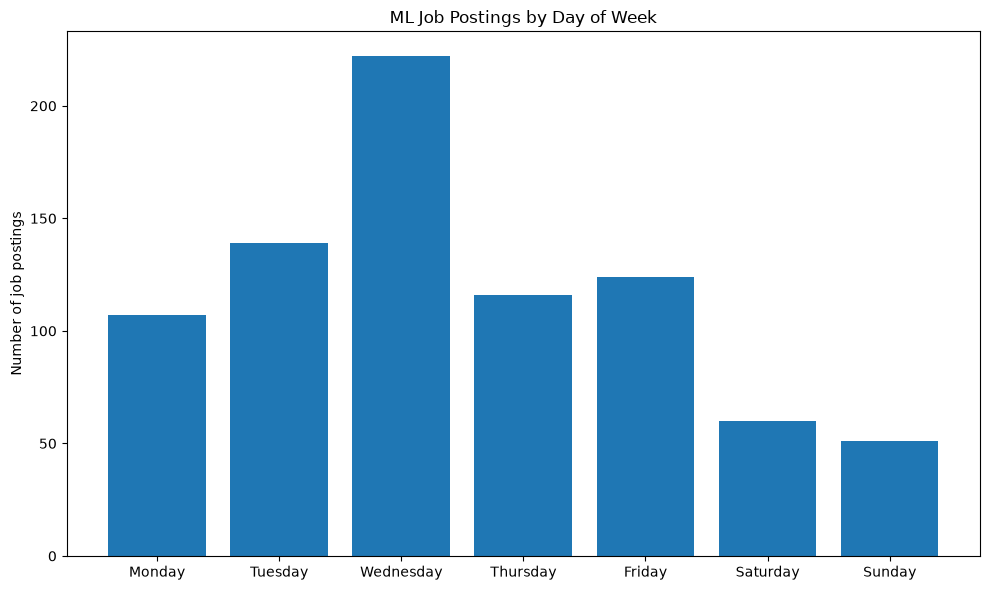

In [37]:
plt.figure(figsize=(10, 6))
plt.bar(day_counts.index, day_counts.values)
plt.ylabel("Number of job postings")
plt.title("ML Job Postings by Day of Week")
plt.tight_layout()
plt.show()

## Exporting the cleaned dataset

Saves the cleaned, US-only dataset (with standardized regions and
extracted date parts) as a checkpoint file for reuse.

df_us.to_csv("cleaned_ml_jobs_us.csv", index=False)